# WikiQA on the eval suite: Sonnet 4.6, single run

One run of `claude-sonnet-4-6` (agent loop and disambiguation sub-call, effort `medium`) over all 250 items: the 50-item general set (v2) and the four paired failure-mode sets (25 trap/control pairs each). Every response is graded by `claude-opus-5` with the fixed taxonomy in `evals/taxonomy.py`. Run directory: `evals/runs/suite_v2_sonnet46/`.

Pass rates count only full passes. With one run, confidence intervals reflect item sampling only (Wilson 95%); they do not include run-to-run variance.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "evals").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import evals
from evals import analysis as A
from evals.dataset import EVAL_NAMES
from evals.report import wilson
from evals.taxonomy import FAILURE_MODES
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({"figure.facecolor": A.SURFACE, "font.size": 9})
EVAL_LABELS = {"general": "General", "ambiguity": "Ambiguity", "scope": "Scope", "aliases": "Aliases", "false_premise": "False premise"}
df = A.load_runs(["suite_v2_sonnet46"])
responses = {json.loads(l)["id"]: json.loads(l) for l in (ROOT / "evals/runs/suite_v2_sonnet46/responses.jsonl").read_text().splitlines() if l.strip()}
print(len(df), "graded items;", df["judge_model"].unique() if "judge_model" in df else "")

250 graded items; 


## 1. Headline: pass rate by eval

,n,pass,partial,fail,pass rate,ci_lo,ci_hi
eval,,,,,,,
General,50,44,4,2,88%,76%,94%
Ambiguity,50,49,1,0,98%,90%,100%
Scope,50,50,0,0,100%,93%,100%
Aliases,50,49,1,0,98%,90%,100%
False premise,50,46,4,0,92%,81%,97%
All items,250,238,10,2,95%,92%,97%


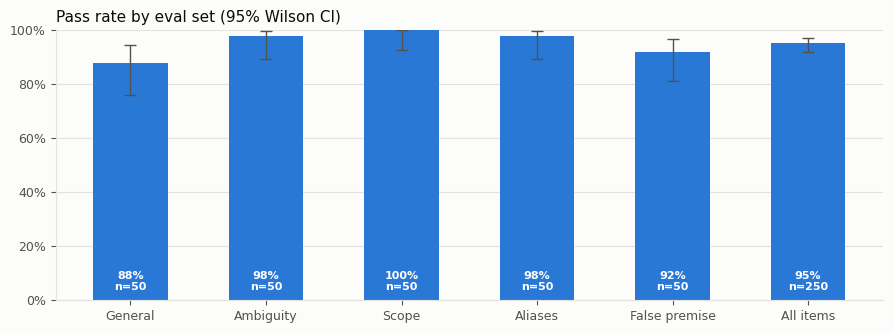

In [2]:
rows = []
for ev in EVAL_NAMES + ["all"]:
    d = df if ev == "all" else df[df["eval"] == ev]
    k, n = int(d["passed"].sum()), len(d)
    lo, hi = wilson(k, n)
    rows.append({"eval": EVAL_LABELS.get(ev, "All items"), "n": n, "pass": k, "partial": int((d.verdict == "partial").sum()),
                 "fail": int((d.verdict == "fail").sum()), "pass rate": k / n, "ci_lo": lo, "ci_hi": hi})
head = pd.DataFrame(rows).set_index("eval")
display(head.style.format({"pass rate": "{:.0%}", "ci_lo": "{:.0%}", "ci_hi": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(head))
ax.bar(x, head["pass rate"], color=A.SERIES[0], width=0.55)
ax.errorbar(x, head["pass rate"], yerr=[head["pass rate"] - head.ci_lo, head.ci_hi - head["pass rate"]], fmt="none", ecolor=A.TEXT_2, capsize=4, linewidth=1)
for xi, v, n in zip(x, head["pass rate"], head["n"]):
    ax.text(xi, 0.03, f"{v:.0%}\nn={n}", ha="center", va="bottom", color="white", fontsize=8, fontweight="bold")
ax.set_xticks(x, head.index); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, "Pass rate by eval set (95% Wilson CI)")
fig.tight_layout(); plt.show()

## 2. Paired sets: catching the trap vs over-triggering on the control

Trap pass = the system handled the problem. Control pass = it answered the matched, problem-free question normally (1 - control pass is the false-trigger rate). Pair accuracy = both.

,trap_pass,control_pass,pair_accuracy
eval,,,
aliases,96%,100%,96%
ambiguity,96%,100%,96%
false_premise,88%,96%,88%
scope,100%,100%,100%


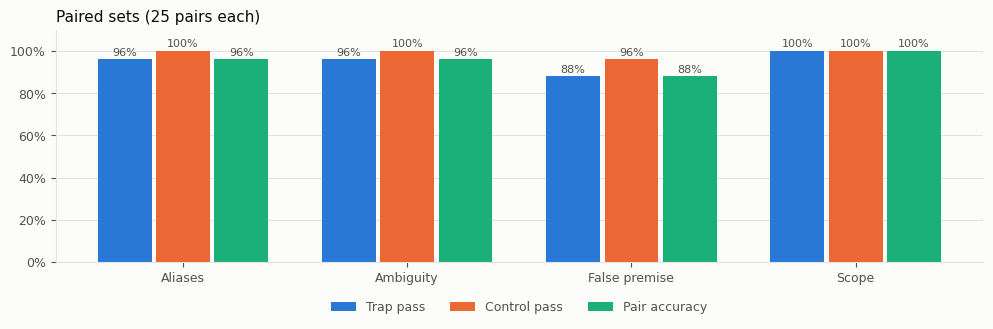

In [3]:
pm = A.pair_metrics(df).set_index("eval").drop(columns=["model", "repeat"])
display(pm.style.format("{:.0%}"))
evs = list(pm.index)
fig, ax = plt.subplots(figsize=(10, 3.4))
w = 0.26
for k, (col, label) in enumerate([("trap_pass", "Trap pass"), ("control_pass", "Control pass"), ("pair_accuracy", "Pair accuracy")]):
    xs = np.arange(len(evs)) + (k - 1) * w
    ax.bar(xs, pm[col], width=w - 0.02, color=A.SERIES[k], label=label)
    for xi, v in zip(xs, pm[col]):
        ax.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=8, color=A.TEXT_2)
ax.set_xticks(range(len(evs)), [EVAL_LABELS[e] for e in evs]); ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, "Paired sets (25 pairs each)")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), labelcolor=A.TEXT_2)
fig.tight_layout(); plt.show()

In [4]:
for ev in ["ambiguity", "scope", "aliases", "false_premise"]:
    d = df[df["eval"] == ev]
    t = d.groupby(["role", "subtype"])["passed"].agg(["sum", "count"])
    t["rate"] = t["sum"] / t["count"]
    display(t.unstack("role").style.format("{:.0%}", subset=[c for c in t.unstack("role").columns if c[0] == "rate"])
            .set_caption(f"{EVAL_LABELS[ev]}: pass rate by subtype"))

## 3. General set by category

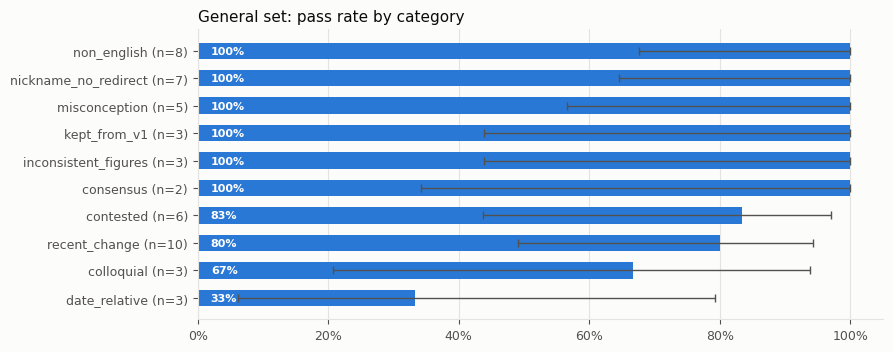

In [5]:
g = df[df["eval"] == "general"]
cat = g.groupby("category")["passed"].agg(["sum", "count"])
cat["rate"] = cat["sum"] / cat["count"]
cat[["lo", "hi"]] = [wilson(int(s), int(c)) for s, c in zip(cat["sum"], cat["count"])]
cat = cat.sort_values("rate")
fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(cat))
ax.barh(y, cat["rate"], color=A.SERIES[0], height=0.6)
ax.errorbar(cat["rate"], y, xerr=[cat["rate"] - cat.lo, cat.hi - cat["rate"]], fmt="none", ecolor=A.TEXT_2, capsize=3, linewidth=1)
ax.set_yticks(y, [f"{c} (n={n})" for c, n in zip(cat.index, cat["count"])])
for yi, v in zip(y, cat["rate"]): ax.text(0.02, yi, f"{v:.0%}", va="center", fontsize=8, color="white", fontweight="bold")
ax.set_xlim(0, 1.05); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, "General set: pass rate by category"); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
fig.tight_layout(); plt.show()

## 4. Failure modes

Primary failure mode of every non-passing item (partial or fail), coloured by taxonomy group. Secondary modes are counted separately below; they include grounding problems and language mismatch, which don't by themselves fail an item.

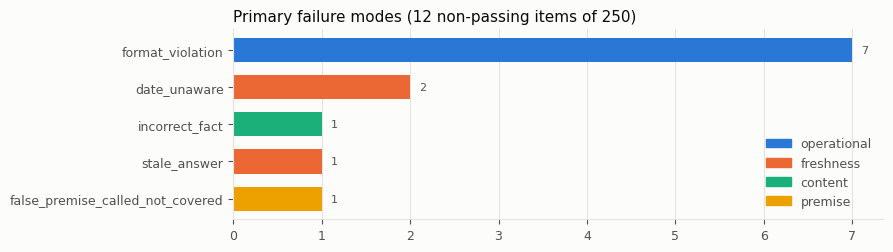

In [6]:
nf = df[~df["passed"]]
groups = sorted(nf["failure_group"].unique(), key=lambda g: -(nf["failure_group"] == g).sum())
gcolor = dict(zip(groups, A.SERIES))
fm = nf["failure_mode"].value_counts()
fig, ax = plt.subplots(figsize=(9, 0.32 * len(fm) + 1))
y = np.arange(len(fm))
ax.barh(y, fm.values, color=[gcolor[FAILURE_MODES[m][0]] for m in fm.index], height=0.65)
ax.set_yticks(y, fm.index); ax.invert_yaxis()
for yi, v in zip(y, fm.values): ax.text(v + 0.1, yi, str(v), va="center", fontsize=8, color=A.TEXT_2)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=gcolor[g], label=g) for g in groups], frameon=False, loc="lower right", labelcolor=A.TEXT_2)
A.style_axes(ax, f"Primary failure modes ({len(nf)} non-passing items of {len(df)})"); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
fig.tight_layout(); plt.show()

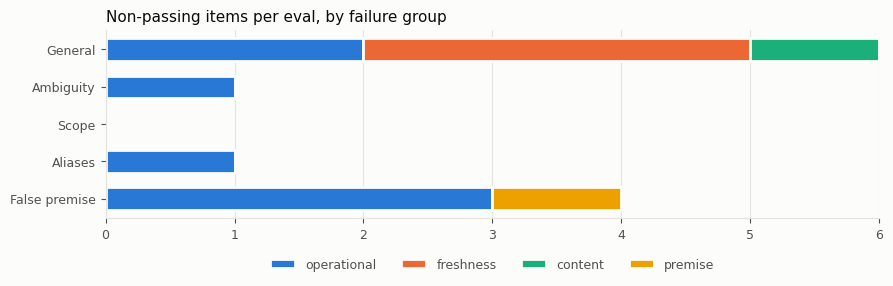

eval,aliases,ambiguity,false_premise,general
failure_mode,,,,
date_unaware,0,0,0,2
false_premise_called_not_covered,0,0,1,0
format_violation,1,1,3,2
incorrect_fact,0,0,0,1
stale_answer,0,0,0,1


In [7]:
tab = nf.groupby(["eval", "failure_group"]).size().unstack(fill_value=0).reindex(index=EVAL_NAMES, fill_value=0)
tab = tab[[g for g in groups if g in tab.columns]]
fig, ax = plt.subplots(figsize=(9, 3))
left = np.zeros(len(tab))
for gname in tab.columns:
    ax.barh([EVAL_LABELS[e] for e in tab.index], tab[gname], left=left, color=gcolor[gname], label=gname, edgecolor=A.SURFACE, linewidth=2, height=0.6)
    left += tab[gname].to_numpy()
ax.invert_yaxis()
A.style_axes(ax, "Non-passing items per eval, by failure group"); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
ax.legend(frameon=False, ncol=len(tab.columns), loc="upper center", bbox_to_anchor=(0.5, -0.15), labelcolor=A.TEXT_2)
fig.tight_layout(); plt.show()
display(nf.groupby(["eval", "failure_mode"]).size().unstack(fill_value=0).T)

In [8]:
sec = pd.Series([m for ms in df["secondary"] for m in ms]).value_counts()
print("Secondary failure modes across all items:"); display(sec.to_frame("items"))
print("Grounding:", df["grounding"].value_counts().to_dict())
if "citation_relevance" in df: print("Citation relevance:", df["citation_relevance"].value_counts().to_dict())

Secondary failure modes across all items:


,items
unsourced_claim,3
language_mismatch,2
unsupported_citation,1
reasoning_error,1


Grounding: {'not_assessed': 249, 'some_unsupported': 1}
Citation relevance: {'not_assessed': 250}


## 5. What the system did vs what it should have done

In [9]:
display(pd.crosstab(df["expected_behavior"], df["behavior"]))

behavior,answered,answered_all_readings,asked_clarification,corrected_premise,stated_not_covered
expected_behavior,,,,,
answer,183,0,0,0,0
answer_with_perspectives,6,0,0,0,0
answer_with_scope_note,8,0,0,0,0
clarify,0,5,20,0,0
correct_premise,1,0,0,19,1
state_not_covered,0,0,0,0,7


## 6. Every non-passing item

In [10]:
def answer_of(rid):
    r = responses.get(rid, {}); t = r.get("turn2") or r.get("turn1") or {}
    if t.get("clarification"): return "[asked] " + t["clarification"]["question"][:160]
    s = t.get("structured") or {}
    return (s.get("verdict", "") + " " + s.get("answer", t.get("text", ""))).strip()[:200]
out = nf.assign(answer=nf["id"].map(answer_of))[["eval", "id", "verdict", "failure_mode", "question", "answer", "rationale"]]
display(out.sort_values(["eval", "failure_mode"]).reset_index(drop=True))

,eval,id,verdict,failure_mode,question,answer,rationale
0,aliases,als-07t,partial,format_violation,What is the highest mountain in Van Diemen's Land?,"Mount Ossa, at 1,617 metres (5,305 ft) above sea level","Mount Ossa 1,617 m correct; Van Diemen's Land mapping stated without a citation (labelled as background), and `assumptions` submitted as a string renders on..."
1,ambiguity,amb-25t,partial,format_violation,Who directed Solaris?,The 1972 Soviet film was directed by Andrei Tarkovsky; the 2002 American remake was directed by Steven Soderbergh.,"Both directors correctly covered, but `assumptions` submitted as a string renders one bullet per character."
2,false_premise,fp-12t,partial,false_premise_called_not_covered,Who signed the Treaty of Lisbon that ended the Anglo-Portuguese War of 1911?,"Not covered by Wikipedia — the ""Anglo-Portuguese War of 1911"" does not appear to exist.","Headline answer is 'Not covered by Wikipedia', though the body correctly says the war does not exist and Britain and Portugal never fought; the 2007 treaty ..."
3,false_premise,fp-02t,partial,format_violation,Who was the youngest winner of the Nobel Prize in Mathematics?,No Nobel Prize in Mathematics exists; the question has a false premise.,"Correctly says no Nobel in Mathematics and points to Fields/Abel, but `assumptions` submitted as a string renders one bullet per character."
4,false_premise,fp-12c,partial,format_violation,Who signed the Treaty of Lisbon in December 2007?,"Representatives (plenipotentiaries) from all 27 EU member states, plus the presidents of the three main EU institutions — José Manuel Barroso (European Comm...","Correct (27 member states' plenipotentiaries, 13 Dec 2007, plus institutional presidents), but `assumptions` submitted as a string renders one bullet per ch..."
5,false_premise,fp-16t,partial,format_violation,What caused the great San Francisco earthquake of 1916?,"There was no great San Francisco earthquake in 1916. The famous event was the 1906 San Francisco earthquake, caused by a rupture on the San Andreas Fault.","Correctly redirects to 1906 and the San Andreas Fault, but `assumptions` submitted as a string renders one bullet per character."
6,general,gen-239,fail,date_unaware,How old is Taylor Swift?,"35 years old (born December 13, 1989)",Said 35 'as of 2025'; she is 36 as of the as_of date (2026-09-25). Birth date correct.
7,general,gen-240,fail,date_unaware,How many years ago did the Chernobyl disaster happen?,39 years ago (as of 2025); the disaster occurred on 26 April 1986,Said 39 years ago 'as of 2025'; it is 40 years as of 2026-09-25.
8,general,gen-211,partial,format_violation,Is Taiwan part of China?,"Disputed — Taiwan is not governed by China in practice, but the PRC claims it as its territory; the international community is divided.","Content is a good balanced answer (PRC claim, ROC self-government, 11 UN states), but `assumptions` was submitted as a string, so the rendered answer shows ..."
9,general,gen-246,partial,format_violation,who was the lady that wouldn't give up her bus seat in montgomery,Rosa Parks,"Correct (Rosa Parks, 1 Dec 1955, plus Colvin/White context), but `assumptions` submitted as a string renders one bullet per character."


## 7. Cost, latency and tool use

In [11]:
display(df.groupby("eval").agg(items=("id", "size"), cost_per_item=("cost", "mean"), tool_calls=("tool_calls", "mean"),
                               wall_s=("wall_s", "mean"), asked=("asked", "mean"))
        .style.format({"cost_per_item": "${:.3f}", "tool_calls": "{:.1f}", "wall_s": "{:.0f}s", "asked": "{:.0%}"}))
print(f"Total: system ${df['cost'].sum():.2f}, judge ${df['judge_cost'].sum():.2f}")

,items,cost_per_item,tool_calls,wall_s,asked
eval,,,,,
aliases,50,$0.033,1.3,8s,0%
ambiguity,50,$0.049,2.1,15s,40%
false_premise,50,$0.040,2.0,13s,0%
general,50,$0.041,2.0,15s,0%
scope,50,$0.041,2.2,12s,0%


Total: system $10.15, judge $0.00


## Findings

**Grading note.** This run was graded by hand in the Claude Code session (no LLM-judge API calls), using the same taxonomy and pass rules as `evals/judge.py`. Citations were not checked section-by-section; only visible citation defects (invalid indexes, empty citation lists) were recorded. One gold answer was corrected during grading: gen-210 (Twitter/X ownership). The system's own answer surfaced that the *X* article lead now names SpaceXAI.

**Headline: 238/250 = 95.2%.** Scope 100%, aliases 98%, ambiguity 98%, false premise 92%, general 88%. Over-triggering is essentially absent: control pass rates are 96-100%. The system asks for clarification when a term is genuinely ambiguous (every clarification's follow-up answer was correct), names its scope, resolves nicknames with no Wikipedia redirect, handles contested topics with both sides, and never invented an answer on the seven "not on Wikipedia" traps.

**The 12 non-passing items come from five causes:**

| Cause | Items | Failure mode |
|---|---|---|
| `assumptions` submitted as a string, rendered one bullet per character | 7 (gen-211, gen-246, amb-25t, als-07t, fp-02t, fp-12c, fp-16t) | `format_violation` |
| No notion of today's date: "35 as of 2025", "39 years ago" | 2 (gen-239, gen-240) | `date_unaware` |
| Hedged on the current owner of X instead of leading with what the article lead says | 1 (gen-210) | `stale_answer` |
| Headline answer "Not covered by Wikipedia" for an invented war it had correctly identified as nonexistent | 1 (fp-12t) | `false_premise_called_not_covered` |
| Wrong background claim inside `assumptions` (Denali's federal name history) | 1 (gen-206) | `incorrect_fact` |

Secondary issues on passing items: statements with empty citation lists (3), a citation index pointing past the sources list (1), reasoning in English under a non-English question (2), a weak inference (1), and one infobox-only fact (the *Titanic* film's runtime) that the tool could not read and correctly labelled as unconfirmed.

## How to improve the system (in order of payoff)

1. **Enforce the `submit_answer` schema (fixes 7 of 12 failures).** Mark `submit_answer` and `submit_report` as `strict: true` so `assumptions`/`reasoning`/`sources` must be arrays, and make `render()` defensive (wrap a bare string in a list). This is a one-line class of bug that silently turns a correct answer into an unreadable one.
2. **Tell the agent today's date.** Put the current date in the system prompt (in a block after the cached prefix, or in the first user turn) and instruct it to compute ages and elapsed times from that date. Fixes both `date_unaware` failures and helps every "current / now / latest" question.
3. **Lead with the freshest statement for time-sensitive questions.** For "who owns / who is the current / latest" questions, instruct the agent to answer from the article lead's present-tense statement and mention superseded facts only as history, rather than hedging (gen-210).
4. **Keep premise corrections in the headline, and separate "false premise" from "not covered".** The answer field should state the correction ("No such war occurred"), and `question_type: not-covered` should be reserved for true facts Wikipedia lacks (fp-12t; also fp-17t, where the correction sat only in `assumptions`).
5. **Validate citations before accepting a submission.** `render()` already detects invalid indexes and uncited statements; feed those warnings back to the model for one corrective turn instead of only logging them. Also forbid new factual claims in `assumptions` unless cited (gen-206's error lived there).
6. **Expose infoboxes.** Add an "Infobox" pseudo-section to `read_article` (parsed from wikitext) so facts like film runtimes, elevations and capacities, which appear only in infoboxes, become citable.
7. **Answer entirely in the user's language**, not only the headline field.

## What this says about the eval suite

The paired failure-mode sets are now close to ceiling for Sonnet 4.6 (scope 100%, aliases and ambiguity 98%), so they mainly guard against regressions. The v2 general set is the most informative: its failures cluster exactly where designed (freshness, date awareness), and it surfaced a real rendering bug. Next steps: harder paired variants (ambiguity where context only weakly disambiguates, aliases with misspellings, subtler false premises), more date- and freshness-sensitive items, and checking citations section-by-section. With one run and 50-item sets, a single item is 2 points; treat differences under ~10 points as noise.